# Mô hình dự đoán việc sinh viên bỏ học

### Tìm hiểu và xử lí dữ liệu thô

In [1]:
import numpy as np
import pandas as pd

In [34]:
data = pd.read_csv('data.csv', sep=';')
data

,Marital status,Application mode,Application order,Course,Daytime/evening attendance\t,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0.0,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,6,6,6,13.666.666.666.666.600,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,6,0,0,0.0,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,6,10,5,12.4,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,6,6,6,13.0,0,13.9,-0.3,0.79,Graduate
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4419,1,1,6,9773,1,1,125.0,1,1,1,...,0,6,8,5,12.666.666.666.666.600,0,15.5,2.8,-4.06,Graduate
4420,1,1,2,9773,1,1,120.0,105,1,1,...,0,6,6,2,11.0,0,11.1,0.6,2.02,Dropout
4421,1,1,1,9500,1,1,154.0,1,37,37,...,0,8,9,1,13.5,0,13.9,-0.3,0.79,Dropout
4422,1,1,1,9147,1,1,180.0,1,37,37,...,0,5,6,5,12.0,0,9.4,-0.8,-3.12,Graduate


Tìm dữ liệu thiếu

In [3]:
nan_value = 0
for i in range(len(data.columns)):
    missing_value = data[data.columns[i]].isna().sum()
    nan_value += missing_value
    print(f"Cot {i} thieu {missing_value} du lieu")
print(f'Data co tong cong {nan_value} du lieu thieu')

Cot 0 thieu 0 du lieu
Cot 1 thieu 0 du lieu
Cot 2 thieu 0 du lieu
Cot 3 thieu 0 du lieu
Cot 4 thieu 0 du lieu
Cot 5 thieu 0 du lieu
Cot 6 thieu 0 du lieu
Cot 7 thieu 0 du lieu
Cot 8 thieu 0 du lieu
Cot 9 thieu 0 du lieu
Cot 10 thieu 0 du lieu
Cot 11 thieu 0 du lieu
Cot 12 thieu 0 du lieu
Cot 13 thieu 0 du lieu
Cot 14 thieu 0 du lieu
Cot 15 thieu 0 du lieu
Cot 16 thieu 0 du lieu
Cot 17 thieu 0 du lieu
Cot 18 thieu 0 du lieu
Cot 19 thieu 0 du lieu
Cot 20 thieu 0 du lieu
Cot 21 thieu 0 du lieu
Cot 22 thieu 0 du lieu
Cot 23 thieu 0 du lieu
Cot 24 thieu 0 du lieu
Cot 25 thieu 0 du lieu
Cot 26 thieu 0 du lieu
Cot 27 thieu 0 du lieu
Cot 28 thieu 0 du lieu
Cot 29 thieu 0 du lieu
Cot 30 thieu 0 du lieu
Cot 31 thieu 0 du lieu
Cot 32 thieu 0 du lieu
Cot 33 thieu 0 du lieu
Cot 34 thieu 0 du lieu
Cot 35 thieu 0 du lieu
Cot 36 thieu 0 du lieu
Data co tong cong 0 du lieu thieu


Sửa lỗi dữ liệu ở các cột điểm

In [38]:
def fix_grade_format(x):
    if pd.isna(x): return x

    val_str = str(x).strip()

    if val_str.count('.') > 1:
        parts = val_str.split('.')
        return pd.to_numeric(parts[0] + '.' + ''.join(parts[1:]))
    
    return pd.to_numeric(val_str)

In [39]:
data['Curricular units 1st sem (grade)'] = data['Curricular units 1st sem (grade)'].apply(fix_grade_format)
data['Curricular units 2nd sem (grade)'] = data['Curricular units 2nd sem (grade)'].apply(fix_grade_format)

In [6]:
print(data.describe().round(2))

       Marital status  Application mode  Application order   Course  \
count         4424.00           4424.00            4424.00  4424.00   
mean             1.18             18.67               1.73  8856.64   
std              0.61             17.48               1.31  2063.57   
min              1.00              1.00               0.00    33.00   
25%              1.00              1.00               1.00  9085.00   
50%              1.00             17.00               1.00  9238.00   
75%              1.00             39.00               2.00  9556.00   
max              6.00             57.00               9.00  9991.00   

       Daytime/evening attendance\t  Previous qualification  \
count                       4424.00                 4424.00   
mean                           0.89                    4.58   
std                            0.31                   10.22   
min                            0.00                    1.00   
25%                            1.00          

In [7]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 37 columns):
 #   Column                                          Non-Null Count  Dtype  
---  ------                                          --------------  -----  
 0   Marital status                                  4424 non-null   int64  
 1   Application mode                                4424 non-null   int64  
 2   Application order                               4424 non-null   int64  
 3   Course                                          4424 non-null   int64  
 4   Daytime/evening attendance	                     4424 non-null   int64  
 5   Previous qualification                          4424 non-null   int64  
 6   Previous qualification (grade)                  4424 non-null   float64
 7   Nacionality                                     4424 non-null   int64  
 8   Mother's qualification                          4424 non-null   int64  
 9   Father's qualification                   

# Tìm hiểu dữ liệu

In [8]:
print(data.columns)

Index(['Marital status', 'Application mode', 'Application order', 'Course',
       'Daytime/evening attendance\t', 'Previous qualification',
       'Previous qualification (grade)', 'Nacionality',
       'Mother's qualification', 'Father's qualification',
       'Mother's occupation', 'Father's occupation', 'Admission grade',
       'Displaced', 'Educational special needs', 'Debtor',
       'Tuition fees up to date', 'Gender', 'Scholarship holder',
       'Age at enrollment', 'International',
       'Curricular units 1st sem (credited)',
       'Curricular units 1st sem (enrolled)',
       'Curricular units 1st sem (evaluations)',
       'Curricular units 1st sem (approved)',
       'Curricular units 1st sem (grade)',
       'Curricular units 1st sem (without evaluations)',
       'Curricular units 2nd sem (credited)',
       'Curricular units 2nd sem (enrolled)',
       'Curricular units 2nd sem (evaluations)',
       'Curricular units 2nd sem (approved)',
       'Curricular units 2nd

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

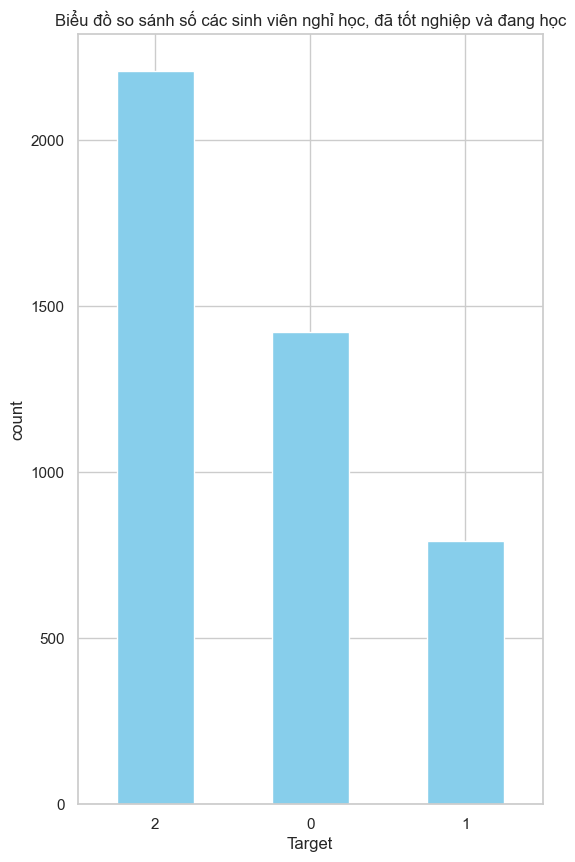

In [32]:
plt.figure(figsize=(6, 10))
data['Target'].value_counts().plot(kind='bar', color='skyblue')

plt.title('Biểu đồ so sánh số các sinh viên nghỉ học, đã tốt nghiệp và đang học')
plt.xlabel('Target')
plt.ylabel('count')
plt.xticks(rotation=0)

plt.show()

In [11]:
data['Target'].value_counts(normalize=True).to_frame()

,proportion
Target,
Graduate,0.499322
Dropout,0.321203
Enrolled,0.179476


C:\Users\Minh Khuê\AppData\Local\Temp\ipykernel_33724\257648172.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


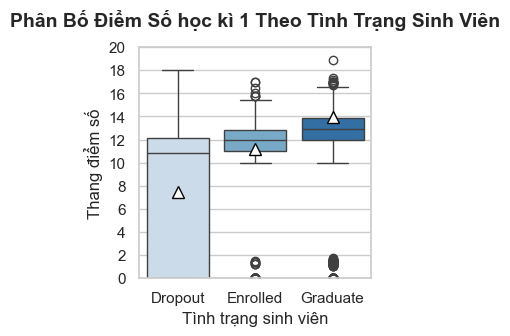

In [43]:
plt.figure(figsize=(3, 3))

sns.set_theme(style="whitegrid")
target_order = ['Dropout', 'Enrolled', 'Graduate'] 

sns.boxplot(
    data=data, 
    x='Target', 
    y='Curricular units 1st sem (grade)', 
    order=target_order,
    palette='Blues',
    showmeans=True,
    meanprops={"marker":"^", "markerfacecolor":"white", "markeredgecolor":"black", "markersize":"8"}
)

plt.title('Phân Bố Điểm Số học kì 1 Theo Tình Trạng Sinh Viên', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Tình trạng sinh viên', fontsize=12)
plt.ylabel('Thang điểm số', fontsize=12)

plt.ylim(0, 20) 
plt.yticks(range(0, 21, 2))

plt.show()

C:\Users\Minh Khuê\AppData\Local\Temp\ipykernel_33724\774329501.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


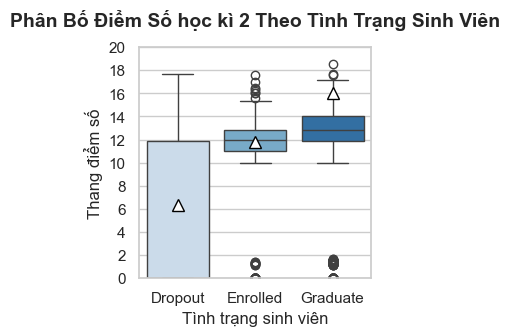

In [42]:
plt.figure(figsize=(3, 3))

sns.set_theme(style="whitegrid")
target_order = ['Dropout', 'Enrolled', 'Graduate'] 

sns.boxplot(
    data=data, 
    x='Target', 
    y='Curricular units 2nd sem (grade)', 
    order=target_order,
    palette='Blues',
    showmeans=True,
    meanprops={"marker":"^", "markerfacecolor":"white", "markeredgecolor":"black", "markersize":"8"}
)

plt.title('Phân Bố Điểm Số học kì 2 Theo Tình Trạng Sinh Viên', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Tình trạng sinh viên', fontsize=12)
plt.ylabel('Thang điểm số', fontsize=12)

plt.ylim(0, 20) 
plt.yticks(range(0, 21, 2))

plt.show()

# Feature engineering

Target encoding: [
    "Course",
    "Application mode",
    "Nacionality",
    "Mother's occupation",
    "Father's occupation",
]

In [14]:
data["Course"].value_counts(normalize=True).to_frame()

,proportion
Course,
9500,0.173146
9147,0.085895
9238,0.080244
9085,0.076175
9773,0.074819
9670,0.060579
9991,0.060579
9254,0.056962
9070,0.051085


In [15]:
# Gộp các phần kết quả học tập trong 2 kì của sinh viên
data['Year_grade'] = (data['Curricular units 1st sem (grade)'] + data['Curricular units 2nd sem (grade)']) / 2
data['Year_grade']

0        0.000000
1       13.833333
2        0.000000
3       12.914286
4       12.666667
          ...    
4419    13.133333
4420    11.500000
4421    81.312500
4422    12.900000
4423    12.333333
Name: Year_grade, Length: 4424, dtype: float64

In [16]:
data["pass_rate_1st"] = data.apply(
    lambda row: (
        row["Curricular units 1st sem (approved)"] / row["Curricular units 1st sem (enrolled)"]
        if row["Curricular units 1st sem (enrolled)"] > 0
        else 0
    ),
    axis=1,
)
data["pass_rate_2nd"] = data.apply(
    lambda row: (
        row["Curricular units 2nd sem (approved)"] / row["Curricular units 2nd sem (enrolled)"]
        if row["Curricular units 2nd sem (enrolled)"] > 0
        else 0
    ),
    axis=1,
)

In [17]:
data["grade_trend"] = (data["Curricular units 2nd sem (grade)"] - data["Curricular units 1st sem (grade)"])

In [18]:
data["pass_rate_trend"] = data["pass_rate_2nd"] - data["pass_rate_1st"]

In [19]:
data["financial_risk"] = ((data['Debtor'] == 1).astype(int) + 
                          (data['Tuition fees up to date'] == 0).astype(int) + 
                          (data['Scholarship holder'] == 0).astype(int) + 
                          (data['Displaced']).astype(int))

In [20]:
drop_feat = ['Curricular units 1st sem (credited)',
            'Curricular units 1st sem (enrolled)',
            'Curricular units 1st sem (evaluations)',
            'Curricular units 1st sem (approved)',
            'Curricular units 1st sem (grade)',
            'Curricular units 1st sem (without evaluations)',
            'Curricular units 2nd sem (credited)',
            'Curricular units 2nd sem (enrolled)',
            'Curricular units 2nd sem (evaluations)',
            'Curricular units 2nd sem (approved)',
            'Curricular units 2nd sem (grade)',
            'Curricular units 2nd sem (without evaluations)',
            'Debtor', 'Tuition fees up to date',
            'Scholarship holder', 'Displaced']
data = data.drop(columns=drop_feat, axis=1)
data.columns

Index(['Marital status', 'Application mode', 'Application order', 'Course',
       'Daytime/evening attendance\t', 'Previous qualification',
       'Previous qualification (grade)', 'Nacionality',
       'Mother's qualification', 'Father's qualification',
       'Mother's occupation', 'Father's occupation', 'Admission grade',
       'Educational special needs', 'Gender', 'Age at enrollment',
       'International', 'Unemployment rate', 'Inflation rate', 'GDP', 'Target',
       'Year_grade', 'pass_rate_1st', 'pass_rate_2nd', 'grade_trend',
       'pass_rate_trend', 'financial_risk'],
      dtype='object')

In [21]:
data['Target'] = data['Target'].map({
    'Dropout':0,
    'Enrolled':1,
    'Graduate':2
})

d:\code\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 9 (	) missing from font(s) Arial.
  fig.canvas.draw()
d:\code\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9 (	) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


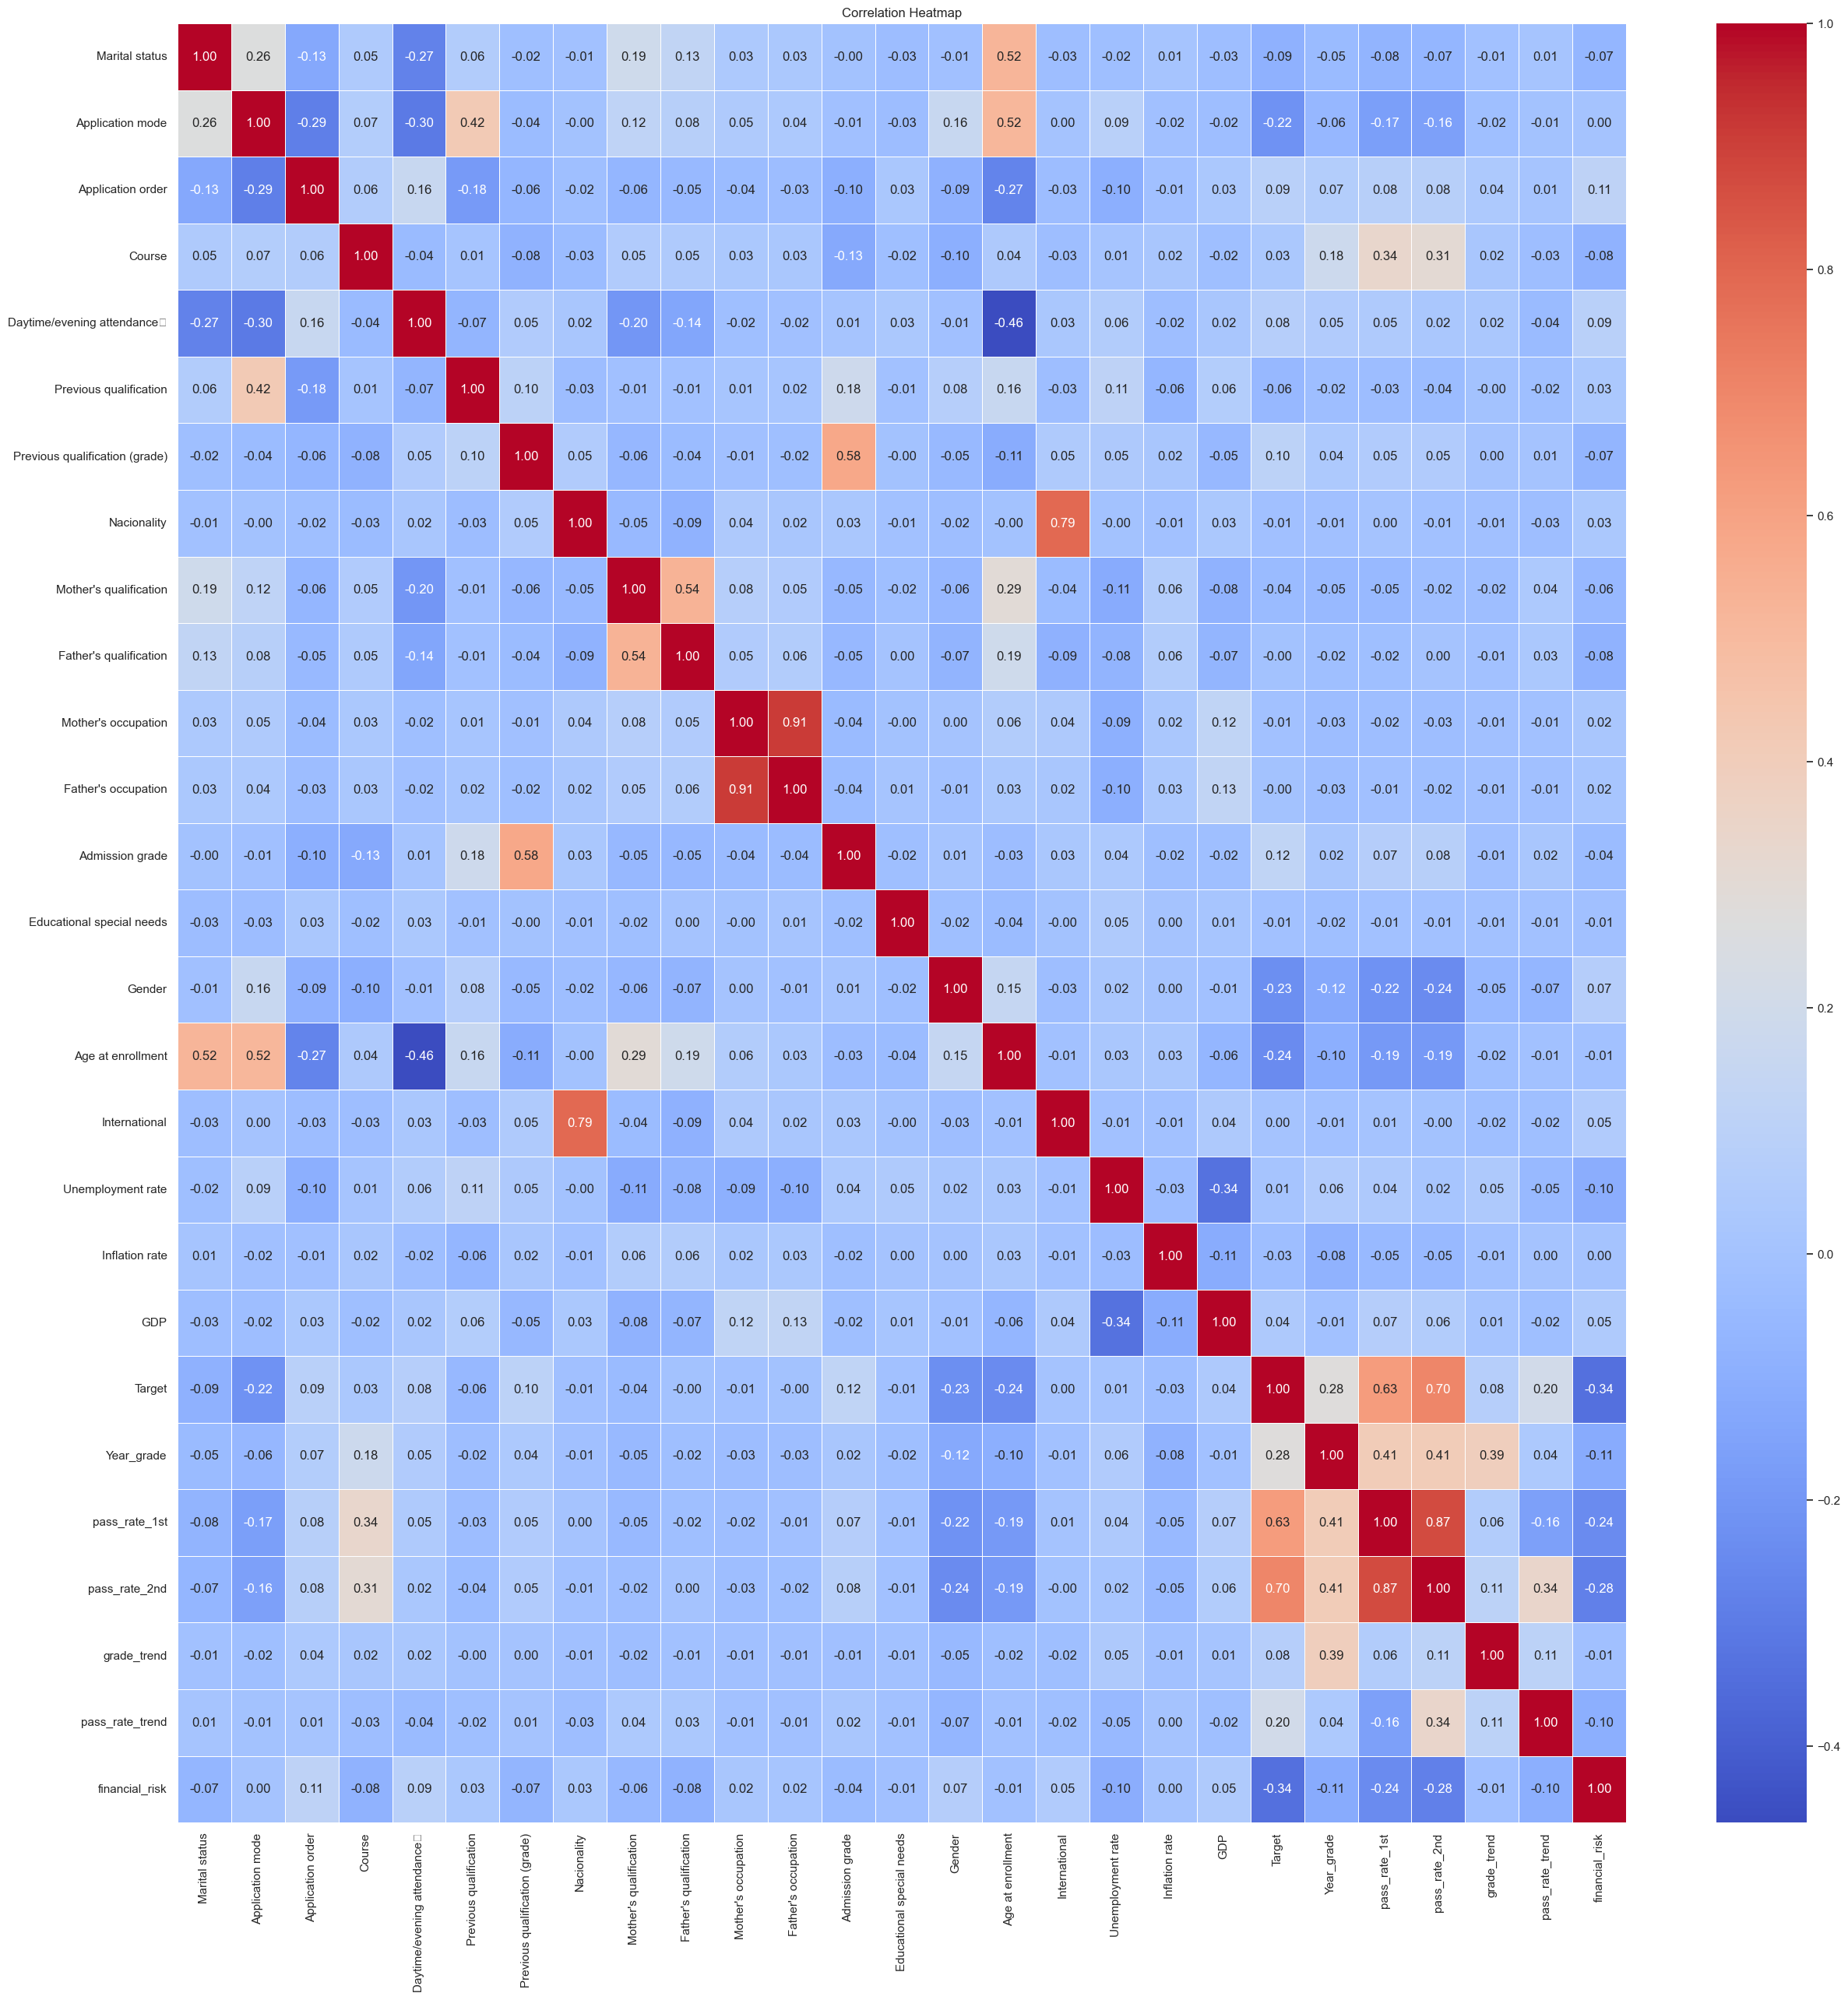

In [22]:
plt.figure(figsize=(30, 30))
sns.heatmap(data.corr() , annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5, )
plt.title('Correlation Heatmap')
plt.show()

In [23]:
target_corr = data.corr()['Target'].abs()

In [24]:
important_feat = target_corr[target_corr > 0.1].index.to_list()
important_feat

['Application mode',
 'Previous qualification (grade)',
 'Admission grade',
 'Gender',
 'Age at enrollment',
 'Target',
 'Year_grade',
 'pass_rate_1st',
 'pass_rate_2nd',
 'pass_rate_trend',
 'financial_risk']

# Train model

In [25]:
new_data = data[important_feat]
new_data

,Application mode,Previous qualification (grade),Admission grade,Gender,Age at enrollment,Target,Year_grade,pass_rate_1st,pass_rate_2nd,pass_rate_trend,financial_risk
0,17,122.0,127.3,1,20,0,0.000000,0.000000,0.000000,0.000000,2
1,15,160.0,142.5,1,19,2,13.833333,1.000000,1.000000,0.000000,3
2,1,122.0,124.8,1,19,0,0.000000,0.000000,0.000000,0.000000,3
3,17,122.0,119.6,0,20,2,12.914286,1.000000,0.833333,-0.166667,2
4,39,100.0,141.5,0,45,2,12.666667,0.833333,1.000000,0.166667,1
...,...,...,...,...,...,...,...,...,...,...,...
4419,1,125.0,122.2,1,19,2,13.133333,0.833333,0.833333,0.000000,1
4420,1,120.0,119.0,0,18,0,11.500000,1.000000,0.333333,-0.666667,4
4421,1,154.0,149.5,0,30,0,81.312500,1.000000,0.125000,-0.875000,1
4422,1,180.0,153.8,0,20,2,12.900000,1.000000,1.000000,0.000000,1


In [26]:
from sklearn.model_selection import train_test_split

X = new_data.drop(columns=['Target'])
y = new_data['Target']
np.random.seed(42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [30]:
from category_encoders import TargetEncoder

encoder = TargetEncoder(cols=['Application mode'])

X_train_encoded = encoder.fit_transform(X_train, y_train)
X_test_encoded = encoder.transform(X_test)

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)

rf_model.fit(X_train, y_train)

y_pred = rf_model.predict(X_test)

print(f"Tổng độ chính xác (Accuracy): {accuracy_score(y_test, y_pred):.4f}\n")
print("Báo cáo chi tiết (Classification Report):")
print(classification_report(y_test, y_pred))

print("Ma trận nhầm lẫn (Confusion Matrix):")
print(confusion_matrix(y_test, y_pred))

Tổng độ chính xác (Accuracy): 0.7424

Báo cáo chi tiết (Classification Report):
              precision    recall  f1-score   support

           0       0.80      0.74      0.77       316
           1       0.49      0.32      0.39       151
           2       0.75      0.90      0.82       418

    accuracy                           0.74       885
   macro avg       0.68      0.65      0.66       885
weighted avg       0.73      0.74      0.73       885

Ma trận nhầm lẫn (Confusion Matrix):


array([[234,  23,  59],
       [ 40,  48,  63],
       [ 17,  26, 375]])